# TP : Segmentation Sémantique avec Segmentation Models PyTorch

Ce TP vous initie à l'utilisation de la bibliothèque `segmentation-models-pytorch` pour réaliser de la segmentation sémantique de manière efficace et moderne. Cette bibliothèque propose une collection d'architectures de segmentation pré-implémentées (U-Net, DeepLabV3+, FPN, etc.) avec des encodeurs pré-entraînés sur ImageNet, permettant de bénéficier du transfer learning sans avoir à réimplémenter ces architectures complexes.

Vous allez utiliser un modèle U-Net avec un encodeur EfficientNet-B3 pré-entraîné pour effectuer la segmentation sémantique d'images de scènes urbaines. L'objectif est de comprendre comment exploiter des bibliothèques modernes pour accélérer le développement, de mettre en place une boucle d'entraînement robuste avec early stopping et suivi des métriques, et d'évaluer les performances du modèle.

Ce TP couvre l'ensemble du workflow professionnel : installation de dépendances, préparation des données, instanciation de modèles avancés, entraînement avec early stopping, visualisation des performances, sauvegarde/chargement de modèle et évaluation finale sur un ensemble de test.

### Installer la bibliothèque segmentation-models-pytorch

Installez la bibliothèque `segmentation-models-pytorch` qui fournit des implémentations prêtes à l'emploi de nombreuses architectures de segmentation sémantique (U-Net, DeepLabV3+, FPN, PSPNet, etc.) avec des encodeurs pré-entraînés sur ImageNet. Cette bibliothèque simplifie grandement la construction de modèles de segmentation performants en permettant de combiner différents encodeurs et décodeurs de manière modulaire. Utilisez pip pour installer le package.

In [2]:
! pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00


In [3]:
import os
import glob
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

import albumentations as A
import segmentation_models_pytorch as smp

from tqdm import tqdm
from tqdm.notebook import tqdm as notebook_tqdm

### Détecter le device de calcul

Créez une variable `device` qui détecte automatiquement le matériel disponible pour l'entraînement : utilisez CUDA si disponible (GPU NVIDIA), sinon MPS pour les Mac avec puce Apple Silicon (M1/M2/M3), sinon le CPU. Affichez le device sélectionné pour confirmer la configuration matérielle.

In [4]:
# Détection du device (mps pour les Mac M1/M2)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

Using device: cpu


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Définir le répertoire des données

Indiquez le chemin vers le répertoire contenant le dataset de segmentation (`../data/seg-dataset`), qui doit contenir des sous-dossiers `train`, `valid` et `test` avec leurs images et masques respectifs.

In [7]:
data_dir = "/content/drive/MyDrive/computer_vision/td13/data/seg-dataset"

### Créer un ensemble de validation (si nécessaire)

Si votre dataset ne contient pas déjà un ensemble de validation, créez-en un à partir d'une partie de l'ensemble d'entraînement :
- Créer les dossiers `valid/images` et `valid/masks`
- Sélectionner aléatoirement 20% des fichiers d'entraînement
- Déplacer ces fichiers vers le dossier de validation

Laissez cette cellule commentée si votre dataset possède déjà un ensemble de validation séparé.

In [ ]:
# # création des dossiers de validation à partir des fichiers train existants

# train_images_dir = os.path.join(data_dir, "train", "images")
# train_masks_dir = os.path.join(data_dir, "train", "masks")

# valid_images_dir = os.path.join(data_dir, "valid", "images")
# valid_masks_dir = os.path.join(data_dir, "valid", "masks")

# os.makedirs(valid_images_dir, exist_ok=True)
# os.makedirs(valid_masks_dir, exist_ok=True)

# image_files = sorted(glob.glob(os.path.join(train_images_dir, "*.png")))
# mask_files = sorted(glob.glob(os.path.join(train_masks_dir, "*.png")))

# num_valid = int(0.2 * len(image_files))
# indices = np.random.choice(len(image_files), num_valid, replace=False)

# for idx in indices:
#     img_src = image_files[idx]
#     mask_src = mask_files[idx]
#     img_dst = os.path.join(valid_images_dir, os.path.basename(img_src))
#     mask_dst = os.path.join(valid_masks_dir, os.path.basename(mask_src))
#     os.rename(img_src, img_dst)
#     os.rename(mask_src, mask_dst)

### Créer la classe `SegDataset` pour Dataset personnalisée

Implémentez la classe `SegDataset` héritant de `torch.utils.data.Dataset` pour charger et préparer les données de segmentation. Cette classe doit inclure :

**Attributs de classe :**
- `IMAGE_SIZE` : tuple définissant la taille de redimensionnement des images (ici : (384, 384))
- `CLASS_MAPPING` : dictionnaire associant les ID de classes (0-11) à leurs noms sémantiques
- `MEAN` et `STD` : valeurs de normalisation ImageNet standard
- `IMAGE_TRANSFORM` : pipeline Albumentations pour les images (resize, normalize, toTensor)
- `MASK_TRANSFORM` : pipeline Albumentations pour les masques (resize, toTensor)

NB : pour mieux généraliser on pourrait ajouter des transformations, mais ceci est un exercice sur un dataset simple

**Méthodes de classe :**
- `unnormalize_image(tensor)` : convertit un tenseur normalisé en image numpy visualisable
- `show_image_and_mask(image, mask, figsize)` : affiche côte à côte une image et son masque

**Méthodes d'instance :**
- `__init__(self, split_dir, image_transform, mask_transform)` : initialise le dataset avec le répertoire du split (train/valid/test) et les transformations
- `__len__(self)` : retourne le nombre d'échantillons
- `__getitem__(self, idx)` : charge une paire image/masque, applique les transformations et retourne les tenseurs (note : convertir le masque en `long` pour la CrossEntropyLoss)

La classe doit charger les images en RGB avec OpenCV et lire les masques avec `IMREAD_UNCHANGED` pour préserver les valeurs de pixels exactes.

In [8]:
class SegDataset(Dataset):

    IMAGE_SIZE = (384, 384)

    CLASS_MAPPING = {
        0: "sky",
        1: "building",
        2: "pole",
        3: "road",
        4: "sidewalk",
        5: "vegetation",
        6: "sign",
        7: "fence",
        8: "vehicle",
        9: "person",
        10: "rider",
        11: "void"
    }

    MEAN = (0.485, 0.456, 0.406)
    STD = (0.229, 0.224, 0.225)

    # NB : pour mieux généraliser on pourrait ajouter des transformations,
    # mais ceci est un exercice sur un dataset simple
    IMAGE_TRANSFORM = A.Compose([
        A.Resize(IMAGE_SIZE[0], IMAGE_SIZE[1]),
        A.Normalize(mean=MEAN, std=STD),
        A.ToTensorV2(),
    ])

    MASK_TRANSFORM = A.Compose([
        A.Resize(IMAGE_SIZE[0], IMAGE_SIZE[1]),
        A.ToTensorV2(),
    ])

    def unnormalize_image(tensor):
        """Convertit un tenseur d'image normalisé en une image numpy non normalisée."""
        image = tensor.numpy().transpose(1, 2, 0)
        image = (image * np.array(SegDataset.STD)) + np.array(SegDataset.MEAN)
        image = np.clip(image * 255, 0, 255).astype(np.uint8)
        return image

    def show_image_and_mask(image, mask, figsize=(10,5)):
        """Affiche une image et son masque de segmentation côte à côte sans color mapping, utilise cmap=tab20."""
        mask = mask.squeeze().numpy()
        plt.figure(figsize=figsize)
        plt.subplot(1, 2, 1)
        plt.imshow(SegDataset.unnormalize_image(image))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='tab20', vmin=0, vmax=len(SegDataset.CLASS_MAPPING)-1)
        plt.title("Mask")
        plt.axis("off")

        plt.show()

    def __init__(self, split_dir, image_transform=IMAGE_TRANSFORM, mask_transform=MASK_TRANSFORM):
        """
        Dataset personnalisé pour la segmentation sémantique.

        Paramètres
        ----------
        split_dir : str
            Chemin vers le dossier du split (train | valid | test) contenant les sous-dossiers 'images' et 'masks'.
        image_transform : callable, optionnel
            Pipeline de transformations Albumentations à appliquer aux images (par défaut : IMAGE_TRANSFORM).
        mask_transform : callable, optionnel
            Pipeline de transformations Albumentations à appliquer aux masques (par défaut : MASK_TRANSFORM).
        """
        self.image_dir = os.path.join(split_dir, "images")
        self.mask_dir = os.path.join(split_dir, "masks")
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.image_files = sorted(glob.glob(os.path.join(self.image_dir, "*.png")))

    def __len__(self):
        """Retourne le nombre d'échantillons dans le dataset."""
        return len(self.image_files)

    def __getitem__(self, idx):
        """
        Charge une paire image/masque à l'index donné, applique les transformations et retourne les tenseurs.

        Paramètres
        ----------
        idx : int
            Index de l'échantillon à charger.

        Retourne
        --------
        image : torch.Tensor
            Image transformée (normalisée, tensorisée).
        mask : torch.Tensor
            Masque transformé (tensorisé, type `long`pour être compatible avec la fonction de perte CrossEntropy (CE) ).
        """
        image = cv2.imread(self.image_files[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.image_transform:
            image = self.image_transform(image=image)["image"]

        mask_path = os.path.join(self.mask_dir, os.path.basename(self.image_files[idx]))
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        if self.mask_transform:
            mask = self.mask_transform(image=mask)["image"]
        return image, mask.long().squeeze() # Convertit en long et squeeze pour supprimer la dimension canal pour la CrossEntropy Loss

### Instancier les datasets

Créez trois instances de `SegDataset` pour les ensembles d'entraînement, de validation et de test en utilisant les chemins appropriés (`train`, `valid`, `test`). Affichez le nombre d'échantillons dans chaque ensemble pour vérifier que les données sont correctement chargées.

In [9]:
train_dataset = SegDataset(split_dir=os.path.join(data_dir, "train"))
valid_dataset = SegDataset(split_dir=os.path.join(data_dir, "valid"))
test_dataset = SegDataset(split_dir=os.path.join(data_dir, "test"))
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(valid_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 367
Number of validation samples: 73
Number of test samples: 101


### Visualiser un exemple du dataset

Sélectionnez un échantillon du dataset de validation (par exemple `num = 40`) :
- chargez l'image et le masque correspondants,
- affichez leurs caractéristiques (forme et plage de valeurs),
- visualisez-les côte à côte avec la méthode `show_image_and_mask` de la classe `SegDataset`.

Image shape: torch.Size([3, 384, 384]), value range: [-2.1007792949676514, 2.6399998664855957]
Mask shape: torch.Size([384, 384]), value range: [0, 11]
Mask dtype: torch.int64


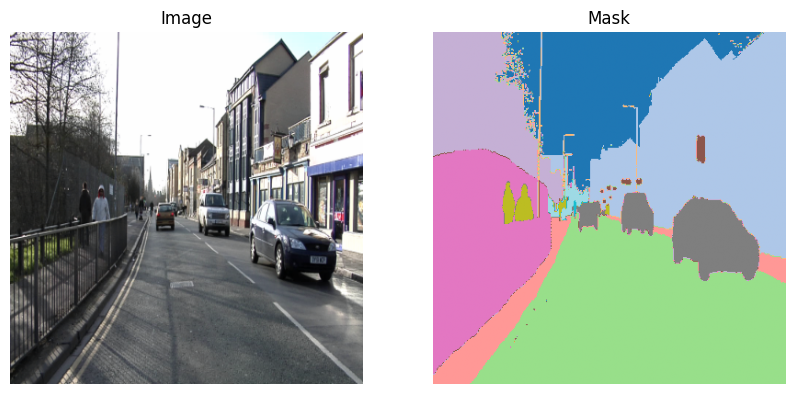

In [10]:
num = 40
image, mask = valid_dataset[num]
print(f"Image shape: {image.shape}, value range: [{image.min()}, {image.max()}]")
print(f"Mask shape: {mask.shape}, value range: [{mask.min()}, {mask.max()}]")
print(f"Mask dtype: {mask.dtype}")

SegDataset.show_image_and_mask(image, mask)

### Créer les DataLoaders

Créez trois `DataLoader` pour les ensembles d'entraînement, de validation et de test. Adaptez la taille de batch en fonction du device (par exemple 8 pour CUDA, 4 pour CPU/MPS). Activez le shuffle uniquement pour le `train_loader`. Affichez le nombre de batchs dans chaque loader pour comprendre l'organisation des données.

In [11]:
BATCH_SIZE = 8 if device.type == 'cuda' else 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in valid_loader: {len(valid_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Batch size: 4
Number of batches in train_loader: 92
Number of batches in valid_loader: 19
Number of batches in test_loader: 26


### Configurer les hyperparamètres d'entraînement

Définissez les hyperparamètres principaux pour l'entraînement : le nombre de classes (basé sur `CLASS_MAPPING`), le learning rate (par exemple `1e-4`), et le nombre d'époques. Ces paramètres contrôleront le comportement de votre modèle et de la boucle d'entraînement.

In [12]:
# Configuration
NUM_CLASSES = SegDataset.CLASS_MAPPING.__len__()

### Instancier un modèle de segmentation avec segmentation-models-pytorch

Créez un modèle de segmentation en utilisant la bibliothèque `segmentation_models_pytorch` (alias `smp`). Utilisez l'architecture U-Net avec un encodeur EfficientNet-B3 pré-entraîné sur ImageNet. Spécifiez le nombre de canaux d'entrée (3 pour RGB) et le nombre de classes de sortie. Déplacez le modèle sur le device approprié.

Note : La bibliothèque offre de nombreuses autres architectures (DeepLabV3+, FPN, etc.) et encodeurs que vous pouvez expérimenter en modifiant les paramètres. Des exemples commentés sont fournis pour référence.

In [13]:
# De nombreuses architectures sont possibles avec segmentation_models_pytorch

model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
)

# model = smp.DeepLabV3Plus(
#     encoder_name="resnet34",
#     encoder_weights="imagenet",
#     in_channels=3,
#     classes=NUM_CLASSES
# )

# model = smp.FPN(
#     encoder_name="efficientnet-b2",
#     encoder_weights="imagenet",
#     in_channels=3,
#     classes=NUM_CLASSES
# )

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

### Tester le modèle non entraîné sur un exemple

Pour vérifier que le modèle fonctionne correctement, effectuez une inférence sur un échantillon du dataset de validation avant l'entraînement. Chargez une image et son masque, ajoutez une dimension batch avec `unsqueeze(0)`, déplacez les tenseurs sur le device, et propagez l'image dans le modèle en mode évaluation (`model.eval()`) sans calcul de gradient. Appliquez `torch.argmax` sur la dimension des classes pour obtenir le masque prédit, et visualisez le résultat. Affichez les formes des tenseurs à chaque étape pour comprendre les transformations de dimensions.

Image shape: torch.Size([3, 384, 384])
Mask shape: torch.Size([384, 384])
Images shape after unsqueeze: torch.Size([1, 3, 384, 384])
Masks shape after unsqueeze: torch.Size([1, 384, 384])
Model output shape: torch.Size([1, 12, 384, 384])
Model output shape after argmax: torch.Size([1, 384, 384])
Mask shape for visualization: torch.Size([384, 384])


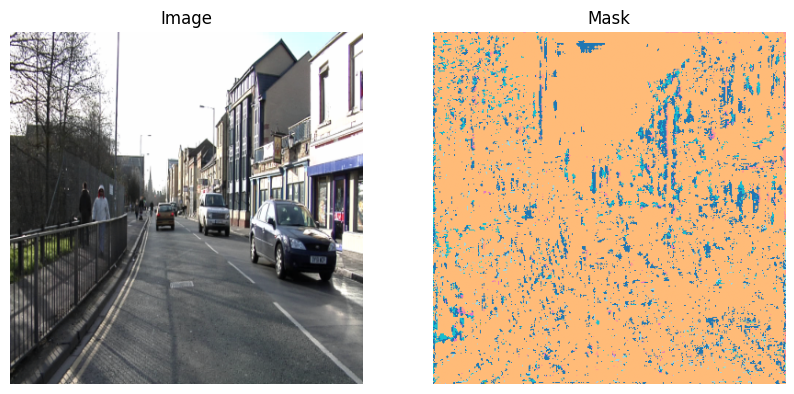

In [14]:
image, mask = valid_dataset[num]
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")

image = image.unsqueeze(0).to(device)  # Ajouter une dimension batch
mask = mask.unsqueeze(0).to(device)    # Ajouter une dimension batch
print(f"Images shape after unsqueeze: {image.shape}")
print(f"Masks shape after unsqueeze: {mask.shape}")

model.eval()
with torch.no_grad():
	preds = model(image)
print(f"Model output shape: {preds.shape}")
preds = torch.argmax(preds, dim=1)
print(f"Model output shape after argmax: {preds.shape}")

pred_mask = preds[0].detach().cpu() # detach pour ne pas garder le lien avec le calcul du gradient et cpu pour visualiser sur le CPU
print(f"Mask shape for visualization: {pred_mask.shape}")

SegDataset.show_image_and_mask(image.squeeze().cpu(), pred_mask.squeeze().cpu())

### Configurer la fonction de perte, l'optimiseur et le scheduler

Instanciez une fonction de perte `CrossEntropyLoss` adaptée à la segmentation multi-classe, un optimiseur AdamW avec weight decay pour régulariser l'entraînement, et un scheduler `ReduceLROnPlateau` qui réduit le learning rate lorsque la perte de validation stagne. Ces composants constituent le coeur de la boucle d'entraînement.

In [15]:
# Loss et optimiseur
LEARNING_RATE = 1e-4
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

### Implémenter les fonctions d'entraînement et d'évaluation

Créez trois fonctions pour gérer le cycle d'entraînement :

**`train_batch(model, data, loss_fn, optimizer, device)`** : entraîne le modèle sur un batch
- Active le mode entraînement avec `model.train()`
- Déplace les données sur le device
- Effectue la passe forward, calcule la perte et l'exactitude (accuracy)
- Effectue la rétropropagation et met à jour les poids
- Retourne la perte et l'exactitude du batch

**`validate_epoch(model, dataloader, loss_fn, device)`** : évalue le modèle sur un ensemble complet
- Active le mode évaluation avec `model.eval()` et désactive les gradients avec `@torch.no_grad()`
- Parcourt tous les batchs du dataloader avec une barre de progression (tqdm)
- Calcule la perte et l'exactitude moyennes sur l'ensemble
- Retourne la perte et l'exactitude moyennes

**`show_validation_prediction(model, dataset, num, device)`** : visualise une prédiction
- Met le modèle en mode évaluation
- Charge un exemple, effectue la prédiction et affiche l'image avec le masque prédit

In [16]:
def train_batch(model, data, loss_fn, optimizer, device):
    """
    Entraîne un batch sur le modèle donné.

    Paramètres
    ----------
    model : nn.Module
        Le modèle à entraîner.
    data : tuple
        Tuple contenant les images et les masques (tensors).
    loss_fn : callable
        Fonction de perte (ex: nn.CrossEntropyLoss).
    optimizer : torch.optim.Optimizer
        Optimiseur pour la mise à jour des poids.
    device : torch.device
        Device sur lequel exécuter le calcul.

    Retourne
    --------
    loss : float
        Valeur de la perte pour ce batch.
    acc : float
        Exactitude (accuracy) du batch.
    """
    model.train()
    data = [d.to(device) for d in data]
    images, masks = data
    preds = model(images)
    optimizer.zero_grad()
    loss = loss_fn(preds, masks)
    acc = (torch.max(preds, 1)[1] == masks).float().mean()
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_epoch(model, dataloader, loss_fn, device):
    """
    Evalue le modèle sur un ensemble complet (validation/test).

    Paramètres
    ----------
    model : nn.Module
        Le modèle à évaluer.
    dataloader : DataLoader
        DataLoader fournissant les batches de données.
    loss_fn : callable
        Fonction de perte (ex: nn.CrossEntropyLoss).
    device : torch.device
        Device sur lequel exécuter le calcul.

    Retourne
    --------
    avg_loss : float
        Perte moyenne sur l'ensemble.
    avg_acc : float
        Exactitude moyenne sur l'ensemble.
    """
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    with tqdm(dataloader, desc="Validating", unit="batch") as t:
        for data in t:
            images, masks = [d.to(device) for d in data]
            preds = model(images)
            loss = loss_fn(preds, masks)
            acc = (torch.max(preds, 1)[1] == masks).float().mean()
            total_loss += loss.item()
            total_acc += acc.item()
            n_batches += 1
            t.set_postfix(loss=loss.item(), acc=acc.item())
    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches
    return avg_loss, avg_acc

@torch.no_grad()
def show_validation_prediction(model, dataset, num, device):
    """
    Affiche la prédiction de segmentation d'un exemple du dataset.

    Paramètres
    ----------
    model : nn.Module
        Le modèle de segmentation à utiliser.
    dataset : torch.utils.data.Dataset
        Le dataset contenant les images et masques.
    num : int
        L'indice de l'exemple à visualiser.
    device : torch.device
        Le device sur lequel exécuter le modèle.

    Cette fonction affiche côte à côte l'image d'entrée et le masque prédit.
    """
    model.eval()
    img, _ = dataset[num]
    img = img.unsqueeze(0).to(device)
    pred = model(img)
    pred_mask = torch.argmax(pred, dim=1)[0].cpu()
    SegDataset.show_image_and_mask(img.squeeze().cpu(), pred_mask, figsize=(8,4))

### Entraîner le modèle avec early stopping

Implémentez la boucle d'entraînement complète avec les fonctionnalités suivantes :

- Définissez le nombre maximum d'époques (par exemple 100) et la patience pour l'early stopping (par exemple 10 époques sans amélioration)
- Pour chaque époque :
  - Entraînez sur tous les batchs de `train_loader` avec une barre de progression (tqdm)
  - Calculez et stockez la perte et l'exactitude moyennes d'entraînement
  - Validez sur `valid_loader` avec la fonction `validate_epoch`
  - Affichez une prédiction de validation tous les 10 époques pour suivre visuellement les progrès
  - Sauvegardez le modèle si la perte de validation s'améliore (fichier temporaire `best.pth`)
  - Incrémentez un compteur si la perte de validation ne s'améliore pas
  - Arrêtez l'entraînement et rechargez le meilleur modèle si la patience est dépassée
- Stockez toutes les métriques dans des listes pour visualisation ultérieure (`train_losses`, `train_accuracies`, `val_losses`, `val_accuracies`)

Note : Remarquez l'utilisation de `loss_fn` (et non `loss`) dans les appels aux fonctions d'entraînement et de validation.

Epoch 1/100


Epoch 1: 100%|██████████| 92/92 [19:50<00:00, 12.94s/batch, acc=0.718, loss=1.25]


Train loss: 1.8378, Train acc: 0.4585


Validating: 100%|██████████| 19/19 [01:25<00:00,  4.49s/batch, acc=0.659, loss=1.25]


Validation loss: 1.2388, Validation acc: 0.6717


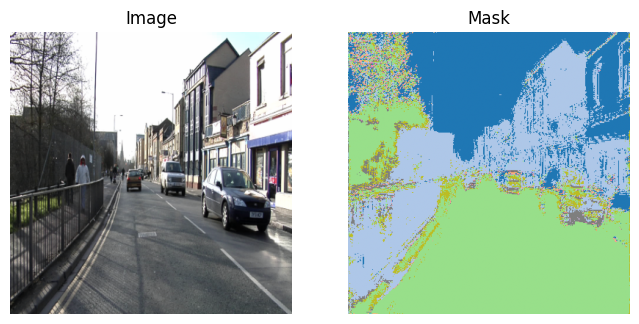

Validation loss improved. Model saved to best.pth (epoch 1, val_loss=1.2388)
------------------------------
Epoch 2/100


Epoch 2: 100%|██████████| 92/92 [16:01<00:00, 10.46s/batch, acc=0.801, loss=0.857]


Train loss: 1.0738, Train acc: 0.7149


Validating: 100%|██████████| 19/19 [00:47<00:00,  2.52s/batch, acc=0.69, loss=1.02]


Validation loss: 0.9001, Validation acc: 0.7491
Validation loss improved. Model saved to best.pth (epoch 2, val_loss=0.9001)
------------------------------
Epoch 3/100


Epoch 3: 100%|██████████| 92/92 [15:58<00:00, 10.41s/batch, acc=0.713, loss=1.09]


Train loss: 0.8464, Train acc: 0.7791


Validating: 100%|██████████| 19/19 [00:48<00:00,  2.56s/batch, acc=0.748, loss=0.899]


Validation loss: 0.7392, Validation acc: 0.8100
Validation loss improved. Model saved to best.pth (epoch 3, val_loss=0.7392)
------------------------------
Epoch 4/100


Epoch 4:  32%|███▏      | 29/92 [05:02<10:52, 10.36s/batch, acc=0.843, loss=0.656]

In [ ]:
n_epochs = 100
patience = 10  # nombre d'époques sans amélioration avant arrêt
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(n_epochs):
    print(f"Epoch {epoch+1}/{n_epochs}")
    model.train()
    model.to(device)
    epoch_loss = 0
    epoch_acc = 0
    with tqdm(train_loader, desc=f"Epoch {epoch+1}", unit="batch") as t:
        for data in t:
            batch_loss, batch_acc = train_batch(model, data, loss_fn, optimizer, device)
            epoch_loss += batch_loss
            epoch_acc += batch_acc
            t.set_postfix(loss=batch_loss, acc=batch_acc)
    avg_loss = epoch_loss / len(train_loader)
    avg_acc = epoch_acc / len(train_loader)
    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)
    print(f"Train loss: {avg_loss:.4f}, Train acc: {avg_acc:.4f}")

    val_loss, val_acc = validate_epoch(model, valid_loader, loss_fn, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    print(f"Validation loss: {val_loss:.4f}, Validation acc: {val_acc:.4f}")

    # show prediction on a validation image every 10 epochs
    if (epoch) % 10 == 0:
        model.eval()
        with torch.no_grad():
            img, true_mask = valid_dataset[num]
            img = img.unsqueeze(0).to(device)
            pred = model(img)
            pred_mask = torch.argmax(pred, dim=1)[0].cpu()
            SegDataset.show_image_and_mask(img.squeeze().cpu(), pred_mask, figsize=(8,4))

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best.pth")
        print(f"Validation loss improved. Model saved to best.pth (epoch {best_epoch}, val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement in validation loss for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}. Loading best model from best.pth (epoch {best_epoch}, val_loss={best_val_loss:.4f})")
            model.load_state_dict(torch.load("best.pth", map_location=device, weights_only=True))
            os.remove("best.pth")
            break

    print("-" * 30)

### Visualiser les courbes d'apprentissage

Tracez l'évolution de la perte (loss) et de l'exactitude (accuracy) pour les ensembles d'entraînement et de validation au fil des époques. Créez deux sous-graphiques côte à côte : un pour la perte et un pour l'exactitude. Ajoutez des légendes, titres et labels d'axes appropriés, et utilisez `plt.tight_layout()` pour une présentation soignée. Cette visualisation permet de diagnostiquer le comportement de l'apprentissage et de détecter d'éventuels surapprentissages ou sous-apprentissages.

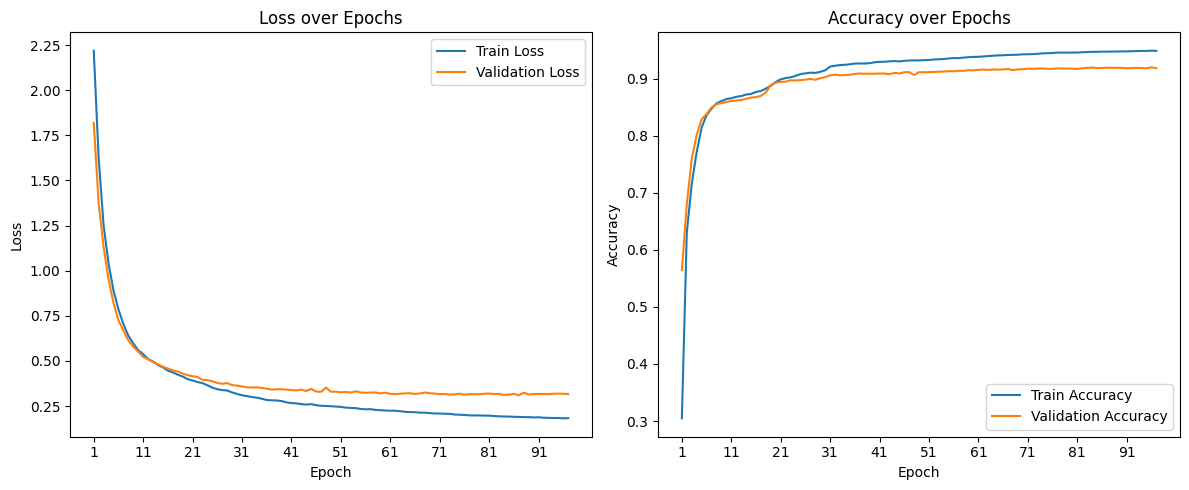

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(range(1, len(train_losses)+1, 10))
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(range(1, len(train_accuracies)+1, 10))
plt.legend()

plt.tight_layout()
plt.show()

### Définir le chemin de sauvegarde du modèle

Construisez le chemin complet pour sauvegarder les poids du modèle en combinant le répertoire de destination (`../model_weights/`) et le nom de fichier (`15_seg_model_train.pth`).

### Sauvegarder les poids du modèle entraîné

Utilisez `torch.save(model.state_dict(), weights_path)` pour sauvegarder les poids du modèle entraîné. Cette ligne est commentée pour éviter d'écraser des poids existants lors des tests. Décommentez-la lorsque vous souhaitez effectivement sauvegarder votre modèle.

In [ ]:
model_weighths_dir = "../model_weights/" # mettez le votre
model_name = "15_seg_model_train.pth"
weights_path = os.path.join(model_weighths_dir, model_name)

In [ ]:
# torch.save(model.state_dict(), weights_path) # commenté pour éviter d'écraser les poids déjà enregistrés
print(f"Model weights saved to {weights_path}")

Model weights saved to ../model_weights/15_seg_model_train.pth


### Évaluer le modèle sur l'ensemble de test

Utilisez la fonction `validate_epoch` pour calculer les performances finales du modèle sur l'ensemble de test. Affichez l'exactitude et la perte de test pour évaluer la capacité de généralisation du modèle sur des données non vues pendant l'entraînement.

In [ ]:
test_loss, test_acc = validate_epoch(model, test_loader, loss_fn, device)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

Validating: 100%|██████████| 13/13 [00:03<00:00,  3.59batch/s, acc=0.913, loss=0.328]

Test Accuracy: 0.9058, Test Loss: 0.3782


### Recharger un modèle sauvegardé

Utilisez `model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))` pour recharger les poids d'un modèle précédemment entraîné. Le paramètre `map_location` garantit que le modèle est chargé sur le bon device. Cette ligne est commentée car le modèle vient d'être entraîné.

### Visualiser une prédiction sur l'ensemble de test

Mettez le modèle en mode évaluation, chargez un exemple de l'ensemble de test (par exemple `num = 0`), effectuez une prédiction sans calcul de gradient, et visualisez le résultat avec `show_image_and_mask`. Cette visualisation qualitative permet d'apprécier la qualité de la segmentation sur des données jamais vues pendant l'entraînement.

In [ ]:
# model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
print(f"Model weights loaded from {weights_path}")

Model weights loaded from ../model_weights/15_seg_model_train.pth


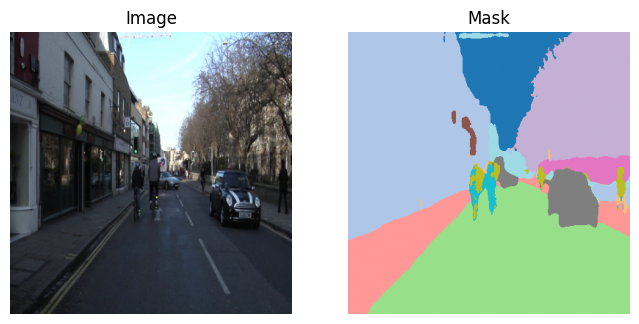

In [ ]:
model.eval()
num = 0 # dans cet exercice, le jeux de test n'est pas très diversifié....
with torch.no_grad():
    img, true_mask = test_dataset[num]
    img = img.unsqueeze(0).to(device)
    pred = model(img)
    pred_mask = torch.argmax(pred, dim=1)[0].cpu()
    SegDataset.show_image_and_mask(img.squeeze().cpu(), pred_mask, figsize=(8,4))